# Домашнее задание 12

In [242]:
import math
import random
import json
from typing import List, Tuple, Dict, Any
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Для нормализации данных и расчета метрик
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PyTorch для построения и обучения нейросетей
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Настройка визуализации и вывода
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [243]:
# Установка seed для воспроизводимости результатов
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Определяем устройство: используем GPU если доступен, иначе CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [244]:
df = pd.read_csv("data/S12-hw-dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


## Подготовка и обзор данных

,count,mean,min,25%,50%,75%,max,std
date,4320,2025-03-31 23:29:59.999999744,2025-01-01 00:00:00,2025-02-14 23:45:00,2025-03-31 23:30:00,2025-05-15 23:15:00,2025-06-29 23:00:00,NaN
target,4320.0,135.60584,69.1,120.5375,135.835,150.625,210.1,21.384633


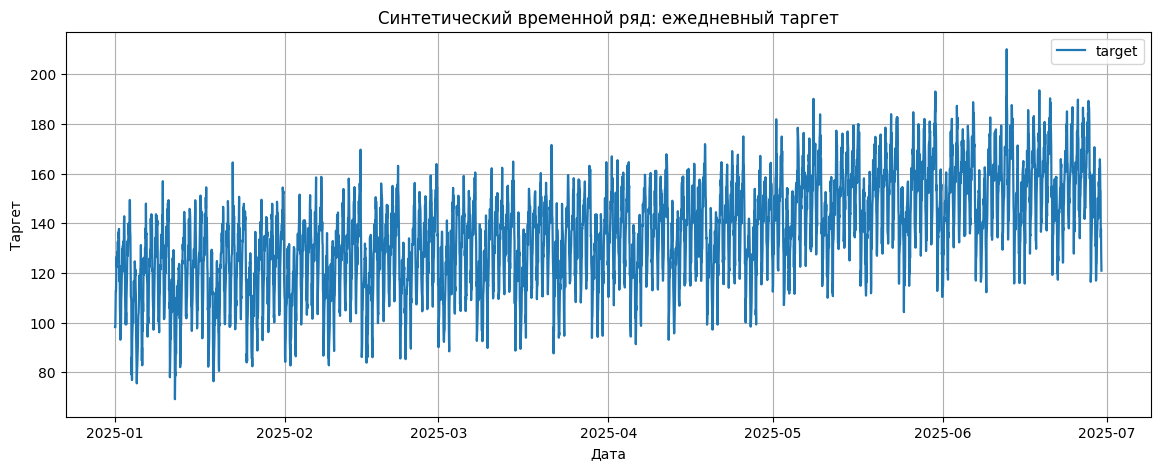

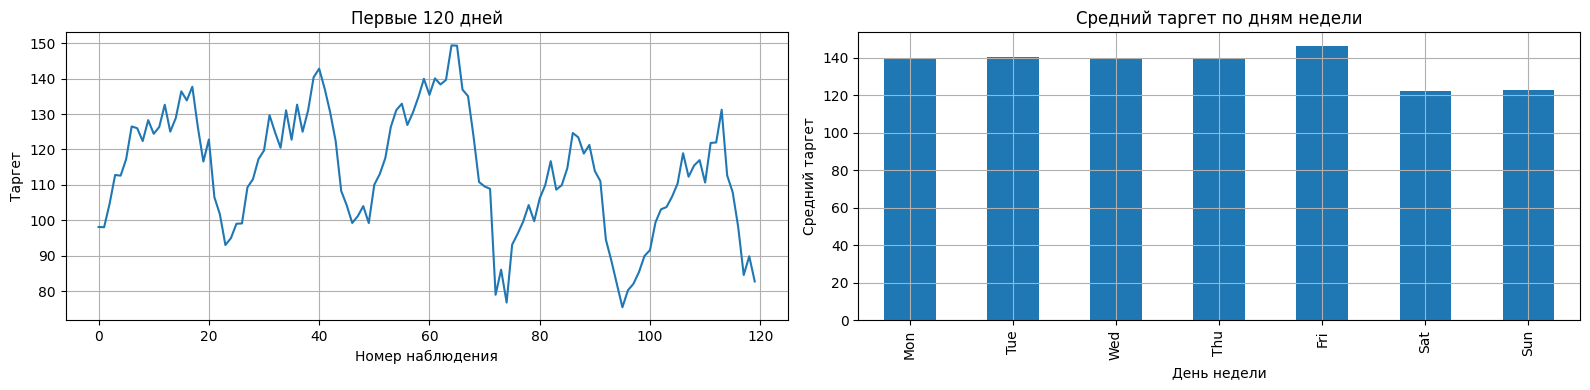

In [245]:
# Сначала смотрим сводную статистику, затем визуально проверяем форму ряда и сезонность.
display(df.describe(include="all").T)

fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, label="target")
ax.set_title("Синтетический временной ряд: ежедневный таргет")
ax.set_xlabel("Дата")
ax.set_ylabel("Таргет")
ax.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Крупным планом видно локальную динамику и уровень шума в начале ряда.
df["target"].iloc[:120].plot(ax=axes[0], title="Первые 120 дней")
axes[0].set_xlabel("Номер наблюдения")
axes[0].set_ylabel("Таргет")

dow_order = [0, 1, 2, 3, 4, 5, 6]
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
(
    df.assign(dayofweek=df["date"].dt.dayofweek)
      .groupby("dayofweek")["target"].mean()
      .reindex(dow_order)
      .set_axis(dow_names)
      .plot(kind="bar", ax=axes[1], title="Средний таргет по дням недели")
)
axes[1].set_xlabel("День недели")
axes[1].set_ylabel("Средний таргет")

plt.tight_layout()
plt.show()

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


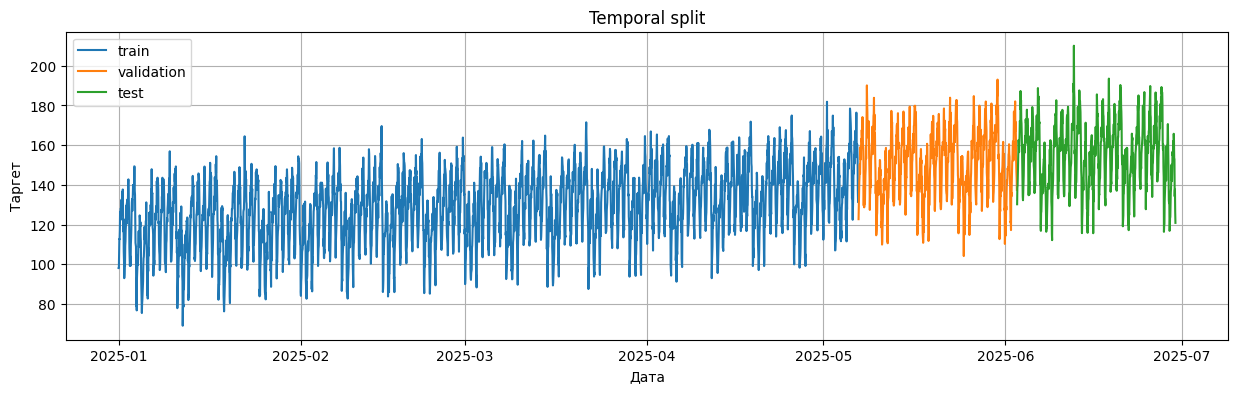

In [246]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

df_gru = df.copy()

train_df, val_df, test_df = temporal_split(df)

print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")
ax.set_title("Temporal split")
ax.set_xlabel("Дата")
ax.set_ylabel("Таргет")
ax.legend()
plt.savefig("artifacts/figures/series_split.png",dpi=300,bbox_inches="tight")
plt.show()

## Дополнительные признаки

In [247]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва между концом и началом периода.
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 2, 3, 7, 14]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    return out

features_df = add_calendar_features(df)
features_df = add_lag_features(features_df)

# Первые строки неизбежно теряются из-за лагов и rolling-окон.
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()

,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_7,lag_14,rolling_mean_7,rolling_std_7
0,2025-01-01 14:00:00,128.87,2,1,0.974928,-0.222521,0.5,0.866025,125.04,132.63,126.35,126.01,98.14,126.445714,3.275621
1,2025-01-01 15:00:00,136.40,2,1,0.974928,-0.222521,0.5,0.866025,128.87,125.04,132.63,122.38,98.07,126.854286,3.388632
2,2025-01-01 16:00:00,133.85,2,1,0.974928,-0.222521,0.5,0.866025,136.40,128.87,125.04,128.28,104.70,128.857143,4.318919
3,2025-01-01 17:00:00,137.71,2,1,0.974928,-0.222521,0.5,0.866025,133.85,136.40,128.87,124.43,112.81,129.652857,4.691868
4,2025-01-01 18:00:00,126.32,2,1,0.974928,-0.222521,0.5,0.866025,137.71,133.85,136.40,126.35,112.62,131.550000,4.907936


In [248]:
feature_cols = [
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
]

target_col = "target"

train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3014, 13) | y_train: (3014,)
X_val:   (646, 13) | y_val:   (646,)
X_test:  (646, 13) | y_test:  (646,)


## Бейзлайны

In [249]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def evaluate_regression(y_true, y_pred, model_name: str) -> pd.DataFrame:
    return pd.DataFrame([{
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE_%": mape(y_true, y_pred),
    }])

# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()

# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()

baseline_results_val = pd.concat([
    evaluate_regression(y_val, val_pred_naive, "B1 | Naive (lag_1)"),
    evaluate_regression(y_val, val_pred_ma7, "B2 | MovingAverage(7)"),
], ignore_index=True)

baseline_results_test = pd.concat([
    evaluate_regression(y_test, test_pred_naive, "B1 | Naive (lag_1)"),
    evaluate_regression(y_test, test_pred_ma7, "B2 | MovingAverage(7)"),
], ignore_index=True)

print("Validation:")
display(baseline_results_val)

print("Test:")
display(baseline_results_test)

Validation:


,model,MAE,RMSE,MAPE_%
0,B1 | Naive (lag_1),6.443406,8.203532,4.394594
1,B2 | MovingAverage(7),12.723717,15.236326,8.828779


Test:


,model,MAE,RMSE,MAPE_%
0,B1 | Naive (lag_1),6.338019,8.059906,4.143508
1,B2 | MovingAverage(7),12.725250,15.226179,8.534403


In [250]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

val_pred_ridge = ridge.predict(X_val_scaled)
test_pred_ridge = ridge.predict(X_test_scaled)


val_results = pd.concat([
    baseline_results_val,
    evaluate_regression(y_val, val_pred_ridge, "B3 | Ridge"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

test_results = pd.concat([
    baseline_results_test,
    evaluate_regression(y_test, test_pred_ridge, "B3 | Ridge"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)

print("Test:")
display(test_results)

Validation:


,model,MAE,RMSE,MAPE_%
0,B3 | Ridge,6.206540,7.671561,4.137207
1,B1 | Naive (lag_1),6.443406,8.203532,4.394594
2,B2 | MovingAverage(7),12.723717,15.236326,8.828779


Test:


,model,MAE,RMSE,MAPE_%
0,B3 | Ridge,5.279720,6.754912,3.432961
1,B1 | Naive (lag_1),6.338019,8.059906,4.143508
2,B2 | MovingAverage(7),12.725250,15.226179,8.534403


## GRU

In [251]:
train_df, val_df, test_df = temporal_split(df_gru)

print(f"train: {train_df.shape}, {train_df['date'].min().date()} -> {train_df['date'].max().date()}")
print(f"val  : {val_df.shape}, {val_df['date'].min().date()} -> {val_df['date'].max().date()}")
print(f"test : {test_df.shape}, {test_df['date'].min().date()} -> {test_df['date'].max().date()}")

train: (3024, 2), 2025-01-01 -> 2025-05-06
val  : (648, 2), 2025-05-07 -> 2025-06-02
test : (648, 2), 2025-06-03 -> 2025-06-29


In [252]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 28

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Создаем обучающие примеры для каждого набора
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


Форма одного окна: (28, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель: -0.8963408


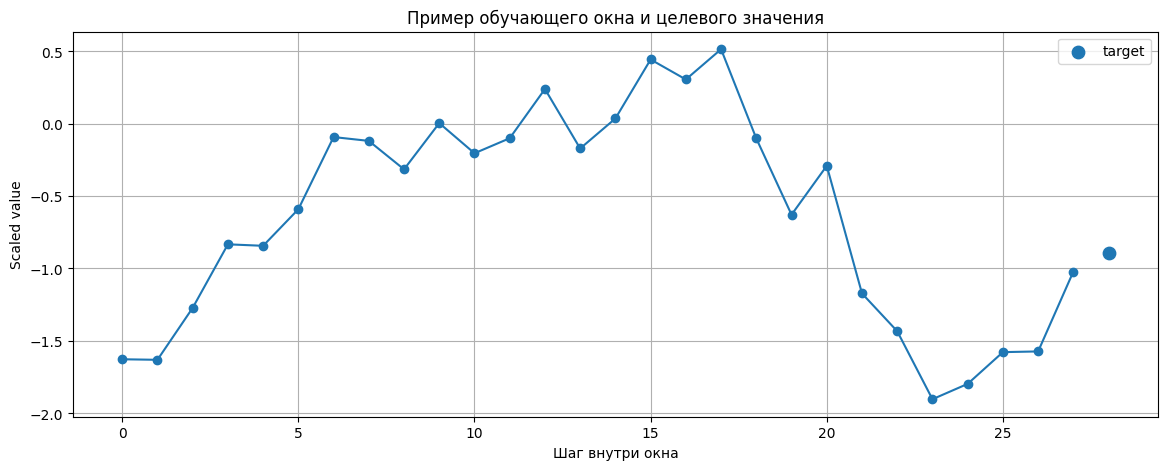

In [253]:
sample_idx = 0

print("Форма одного окна:", X_train[sample_idx].shape)
print("Первые 5 значений окна:", X_train[sample_idx][:5].ravel())
print("Цель:", y_train[sample_idx])

fig, ax = plt.subplots()
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o")
ax.scatter([window_size], [y_train[sample_idx]], s=80, label="target")
ax.set_title("Пример обучающего окна и целевого значения")
ax.set_xlabel("Шаг внутри окна")
ax.set_ylabel("Scaled value")
ax.legend()
plt.show()

In [254]:
class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверяем форму батча
xb, yb = next(iter(train_loader))
print("Batch X:", xb.shape)  # (batch_size, window_size, 1)
print("Batch y:", yb.shape)  # (batch_size,)

Batch X: torch.Size([64, 28, 1])
Batch y: torch.Size([64])


In [255]:
class GRUForecaster(nn.Module):
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred
    
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [256]:
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=35, lr=5e-4, device=device)

GRU  params: 37889


Epoch 01 | train_loss=0.6717 | val_loss=0.5619
Epoch 02 | train_loss=0.2485 | val_loss=0.2604
Epoch 03 | train_loss=0.1615 | val_loss=0.2055
Epoch 04 | train_loss=0.1537 | val_loss=0.1853
Epoch 05 | train_loss=0.1491 | val_loss=0.2427
Epoch 06 | train_loss=0.1480 | val_loss=0.2478
Epoch 07 | train_loss=0.1467 | val_loss=0.1839
Epoch 08 | train_loss=0.1433 | val_loss=0.1870
Epoch 09 | train_loss=0.1444 | val_loss=0.2102
Epoch 10 | train_loss=0.1411 | val_loss=0.1823
Epoch 11 | train_loss=0.1361 | val_loss=0.2171
Epoch 12 | train_loss=0.1302 | val_loss=0.2027
Epoch 13 | train_loss=0.1203 | val_loss=0.2184
Epoch 14 | train_loss=0.1113 | val_loss=0.2201
Epoch 15 | train_loss=0.1077 | val_loss=0.2163
Epoch 16 | train_loss=0.1046 | val_loss=0.2524
Epoch 17 | train_loss=0.1042 | val_loss=0.2627
Epoch 18 | train_loss=0.1037 | val_loss=0.1853
Epoch 19 | train_loss=0.1063 | val_loss=0.1835
Epoch 20 | train_loss=0.1000 | val_loss=0.2004
Epoch 21 | train_loss=0.1010 | val_loss=0.1913
Epoch 22 | tr

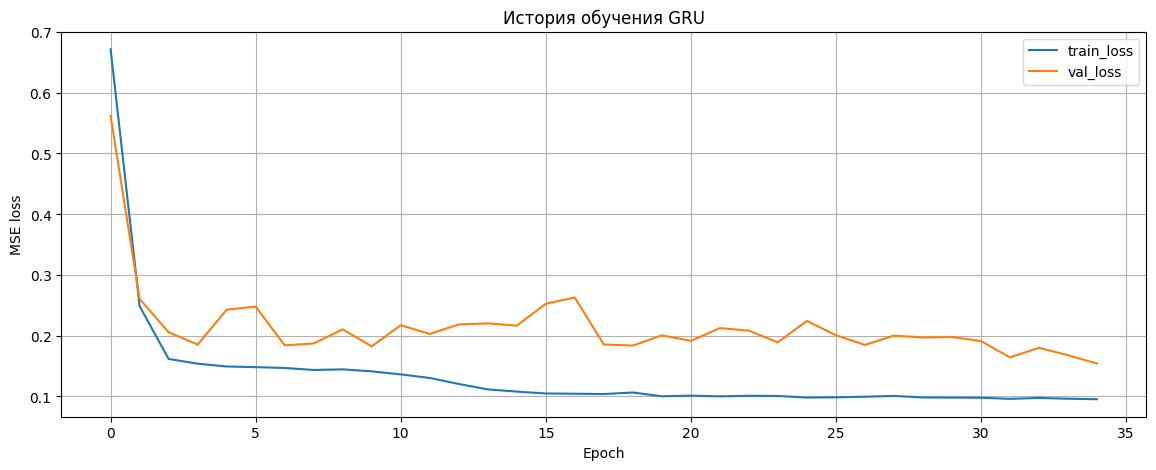

In [257]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png",dpi=300,bbox_inches="tight")
plt.show()

In [258]:
@torch.no_grad()
def predict_model(model, loader, device):
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets

def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)
gru_val_true = inverse_scale(gru_val_true_scaled, scaler)

val_results = pd.concat([
    val_results,
    evaluate_regression(gru_val_true, gru_val_pred, "R1 | GRU"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

gru_test_pred_scaled, gru_test_true_scaled = predict_model(gru_model, test_loader, device)
gru_test_pred = inverse_scale(gru_test_pred_scaled, scaler)
gru_test_true = inverse_scale(gru_test_true_scaled, scaler)

test_results = pd.concat([
    test_results,
    evaluate_regression(gru_test_true, gru_test_pred, "R1 | GRU"),
], ignore_index=True).sort_values("MAE").reset_index(drop=True)

print("Validation:")
display(val_results)

print("Test:")
display(test_results)

Validation:


,model,MAE,RMSE,MAPE_%
0,R1 | GRU,5.646246,7.282123,3.814952
1,B3 | Ridge,6.206540,7.671561,4.137207
2,B1 | Naive (lag_1),6.443406,8.203532,4.394594
3,B2 | MovingAverage(7),12.723717,15.236326,8.828779


Test:


,model,MAE,RMSE,MAPE_%
0,B3 | Ridge,5.279720,6.754912,3.432961
1,B1 | Naive (lag_1),6.338019,8.059906,4.143508
2,R1 | GRU,6.722275,8.508033,4.344639
3,B2 | MovingAverage(7),12.725250,15.226179,8.534403


## Обзор результатов

Лучшая модель на test: B3 | Ridge


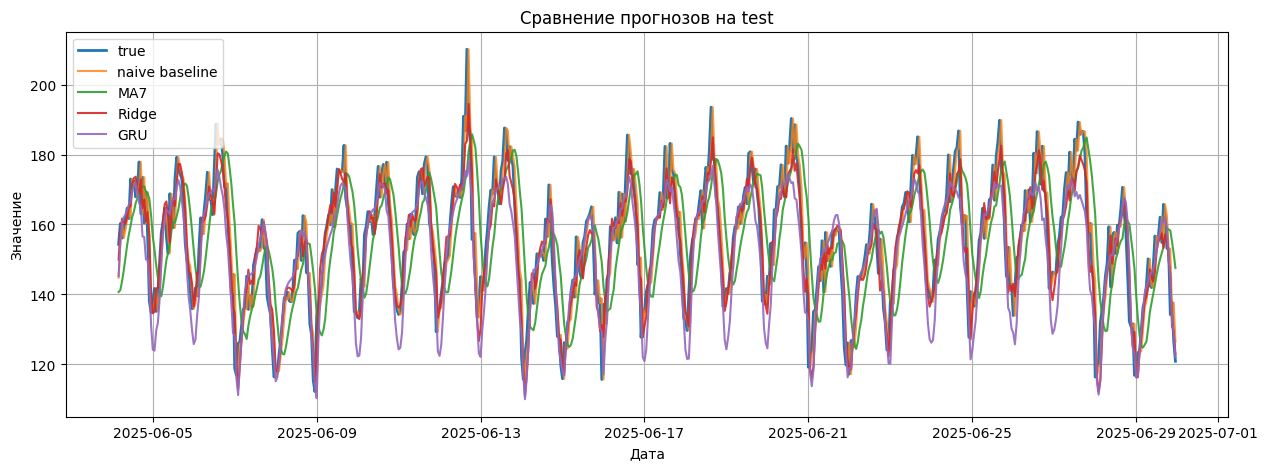

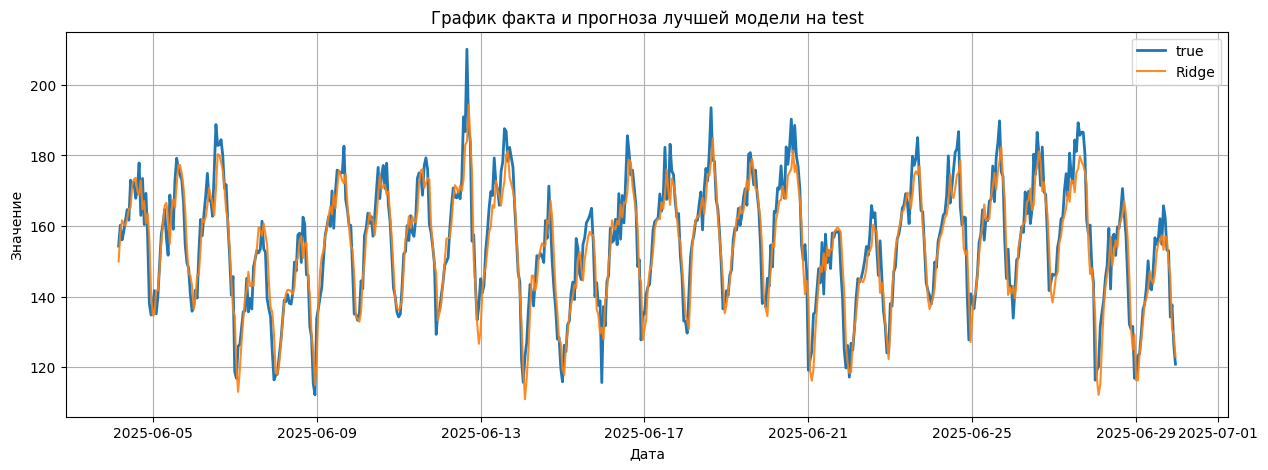

In [259]:
best_model_name = test_results.iloc[0]["model"]
print("Лучшая модель на test:", best_model_name)

plot_df = pd.DataFrame(
    {
        "date": test_df["date"].iloc[window_size:].reset_index(drop=True),
        "true": gru_test_true,
        "naive":test_pred_naive[-len(gru_test_pred):],
        "ma7": test_pred_ma7[-len(gru_test_pred):],
        "ridge": test_pred_ridge[-len(gru_test_pred):],
        "gru": gru_test_pred,
    }
)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["naive"], label="naive baseline", alpha=0.8)
ax.plot(plot_df["date"], plot_df["ma7"], label="MA7", alpha=0.9)
ax.plot(plot_df["date"], plot_df["ridge"], label="Ridge", alpha=0.9)
ax.plot(plot_df["date"], plot_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(plot_df["date"], plot_df["true"], label="true", lw=2)
ax.plot(plot_df["date"], plot_df["ridge"], label="Ridge", alpha=0.9)
ax.set_title("График факта и прогноза лучшей модели на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig("artifacts/figures/best_forecast_test.png",dpi=300,bbox_inches="tight")
plt.show()

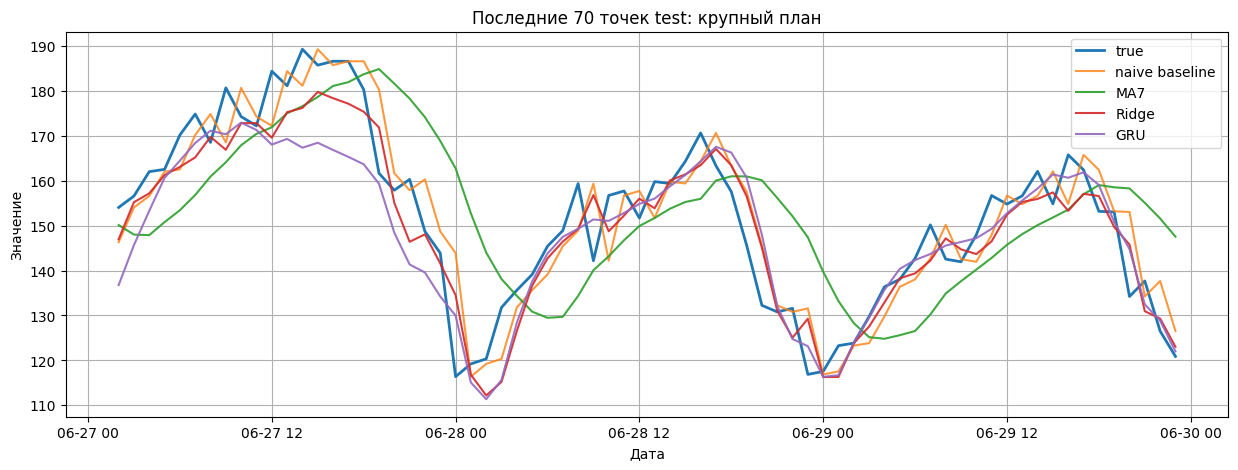

In [260]:
fig, ax = plt.subplots(figsize=(15, 5))
tail_df = plot_df.tail(70)
ax.plot(tail_df["date"], tail_df["true"], label="true", lw=2)
ax.plot(tail_df["date"], tail_df["naive"], label="naive baseline", alpha=0.8)
ax.plot(tail_df["date"], tail_df["ma7"], label="MA7", alpha=0.9)
ax.plot(tail_df["date"], tail_df["ridge"], label="Ridge", alpha=0.9)
ax.plot(tail_df["date"], tail_df["gru"], label="GRU", alpha=0.9)
ax.set_title("Последние 70 точек test: крупный план")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.show()

## Сохранение артефактов

In [261]:
runs = pd.DataFrame(columns=[
    "experiment_id","task","dataset","seed","split_summary",
    "window_size","horizon","model_summary","features_summary",
    "scaler","optimizer","lr","epochs_trained","best_val_mae",
    "best_val_rmse","best_val_mape","test_mae","test_rmse",
    "test_mape","notes"
])

def get_metrics(df, model_name):
    row = df[df["model"] == model_name].iloc[0]
    return row["MAE"], row["RMSE"], row["MAPE_%"]

val_mae, val_rmse, val_mape = get_metrics(val_results, "B1 | Naive (lag_1)")
test_mae, test_rmse, test_mape = get_metrics(test_results, "B1 | Naive (lag_1)")

runs.loc[len(runs)] = [
    "B1","forecasting","S12-hw-dataset",42,
    "70/15/15 temporal split",
    window_size, 1, 
    "Naive: y[t-1]",
    "target only",
    "StandardScaler",
    None,None,None,
    val_mae,val_rmse,val_mape,
    test_mae,test_rmse,test_mape,
    "naive baseline"
]

val_mae, val_rmse, val_mape = get_metrics(val_results, "B2 | MovingAverage(7)")
test_mae, test_rmse, test_mape = get_metrics(test_results, "B2 | MovingAverage(7)")

runs.loc[len(runs)] = [
    "B2","forecasting","S12-hw-dataset",42,
    "70/15/15 temporal split",
    window_size, 1, 
    "Moving Average (7)",
    "target only",
    "StandardScaler",
    None,None,None,
    val_mae,val_rmse,val_mape,
    test_mae,test_rmse,test_mape,
    "MA7 baseline"
]

val_mae, val_rmse, val_mape = get_metrics(val_results, "B3 | Ridge")
test_mae, test_rmse, test_mape = get_metrics(test_results, "B3 | Ridge")

runs.loc[len(runs)] = [
    "B3","forecasting","S12-hw-dataset",42,
    "70/15/15 temporal split",
    window_size,1,
    "Ridge(alpha=1.0)",
    "lags + calendar + rolling",
    "StandardScaler",
    None,None,None,
    val_mae,val_rmse,val_mape,
    test_mae,test_rmse,test_mape,
    "linear baseline"
]

val_mae, val_rmse, val_mape = get_metrics(val_results, "R1 | GRU")
test_mae, test_rmse, test_mape = get_metrics(test_results, "R1 | GRU")

runs.loc[len(runs)] = [
    "R1","forecasting","S12-hw-dataset",42,
    "70/15/15 temporal split",
    window_size,1,
    "GRU(hidden=64, layers=2)",
    "target only (univariate)",
    "StandardScaler",
    "Adam",
    5e-4,
    35,
    val_mae,val_rmse,val_mape,
    test_mae,test_rmse,test_mape,
    "GRU model"
]

runs.to_csv("artifacts/runs.csv", index=False)
runs

C:\Users\maxim\AppData\Local\Temp\ipykernel_27984\1377554620.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  runs.loc[len(runs)] = [


,experiment_id,task,dataset,seed,split_summary,window_size,horizon,model_summary,features_summary,scaler,optimizer,lr,epochs_trained,best_val_mae,best_val_rmse,best_val_mape,test_mae,test_rmse,test_mape,notes
0,B1,forecasting,S12-hw-dataset,42,70/15/15 temporal split,28,1,Naive: y[t-1],target only,StandardScaler,None,NaN,None,6.443406,8.203532,4.394594,6.338019,8.059906,4.143508,naive baseline
1,B2,forecasting,S12-hw-dataset,42,70/15/15 temporal split,28,1,Moving Average (7),target only,StandardScaler,None,NaN,None,12.723717,15.236326,8.828779,12.725250,15.226179,8.534403,MA7 baseline
2,B3,forecasting,S12-hw-dataset,42,70/15/15 temporal split,28,1,Ridge(alpha=1.0),lags + calendar + rolling,StandardScaler,None,NaN,None,6.206540,7.671561,4.137207,5.279720,6.754912,3.432961,linear baseline
3,R1,forecasting,S12-hw-dataset,42,70/15/15 temporal split,28,1,"GRU(hidden=64, layers=2)",target only (univariate),StandardScaler,Adam,0.0005,35,5.646246,7.282123,3.814952,6.722275,8.508033,4.344639,GRU model


In [262]:
torch.save(gru_model.state_dict(), "artifacts/best_gru.pt")

In [263]:
best_config = {
    "experiment_id": "R1",
    "model": "GRU",
    "dataset": "S12-hw-dataset",
    "features": "target, dayofweek, month, dow_sin, dow_cos,month_sin, month_cos, lag_1, lag_2, lag_3, lag_7, lag_14, rolling_mean_7, rolling_std_7",
    "window_size": window_size,
    "horizon": 1,
    "input_size": X_train.shape[2],
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.0,
    "batch_size": 32,
    "optimizer": "Adam",
    "learning_rate": 5e-4,
    "epochs": 35,
    "scaler": "StandardScaler",
    "best_val_mae": float(val_mae),
    "test_mae": float(test_mae),
    "seed": 42
}

with open("artifacts/best_gru_config.json","w") as f:
    json.dump(best_config,f,indent=4)

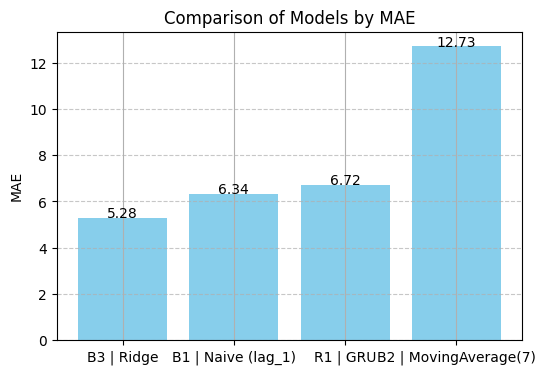

In [264]:
plt.figure(figsize=(6,4))
plt.bar(test_results['model'], test_results["MAE"], color='skyblue')
plt.ylabel("MAE")
plt.title(f'Comparison of Models by {"MAE"}')
for i, v in enumerate(test_results["MAE"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('artifacts/figures/baselines_compare.png', dpi=300, bbox_inches='tight')
plt.show()